# DA5401 A5: Visualizing Data Veracity Challenges in Multi-Label Classification

---

## Assignment Details

* **Course:** DA5401-DATA ANALYSIS LAB
* **Assignment:** A5 - Manifold Visualization
* **Objective:** To visually inspect the **Yeast Dataset** for data veracity issues (noisy labels, outliers, hard-to-learn samples) using **t-SNE** and **Isomap** dimensionality reduction techniques.

## Author's Information

* **Name:** JAYDEEP MAKWANA
* **Roll Number:** DA25M013
* **Date:** 05/10/2025

## 1. Setup and Library Imports

This section imports all necessary Python libraries for data manipulation, preprocessing, dimensionality reduction, and visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE, Isomap

# Set visualization style

In [2]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = [12, 8]
print("Libraries imported successfully.")

Libraries imported successfully.


# 2. Data Loading and Inspection

Dataset loaded successfully.
Shape of the dataset: (2417, 117)

--- First 5 Rows of the Dataset ---
       Att1      Att2      Att3      Att4      Att5      Att6      Att7  \
0  0.004168 -0.170975 -0.156748 -0.142151  0.058781  0.026851  0.197719   
1 -0.103956  0.011879 -0.098986 -0.054501 -0.007970  0.049113 -0.030580   
2  0.509949  0.401709  0.293799  0.087714  0.011686 -0.006411 -0.006255   
3  0.119092  0.004412 -0.002262  0.072254  0.044512 -0.051467  0.074686   
4  0.042037  0.007054 -0.069483  0.081015 -0.048207  0.089446 -0.004947   

       Att8      Att9     Att10  ...  Class5  Class6  Class7  Class8  Class9  \
0  0.041850  0.066938 -0.056617  ...    b'0'    b'0'    b'1'    b'1'    b'0'   
1 -0.077933 -0.080529 -0.016267  ...    b'0'    b'0'    b'0'    b'0'    b'0'   
2  0.013646 -0.040666 -0.024447  ...    b'0'    b'0'    b'0'    b'0'    b'0'   
3 -0.007670  0.079438  0.062184  ...    b'0'    b'0'    b'0'    b'0'    b'0'   
4  0.064456 -0.133387  0.068878  ...    b'1'    b

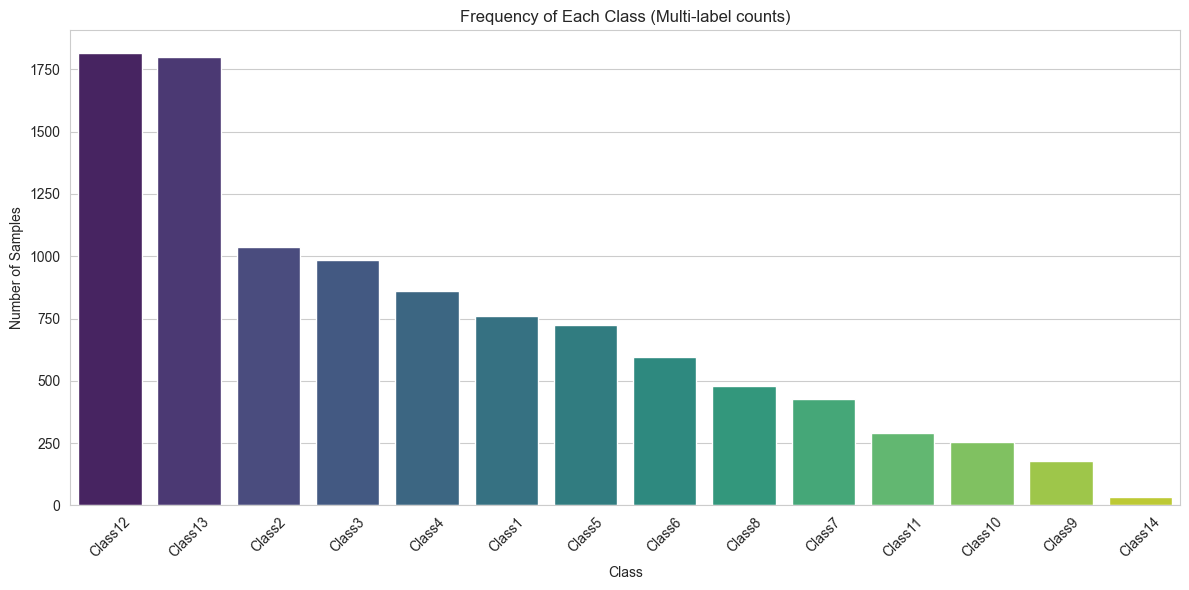

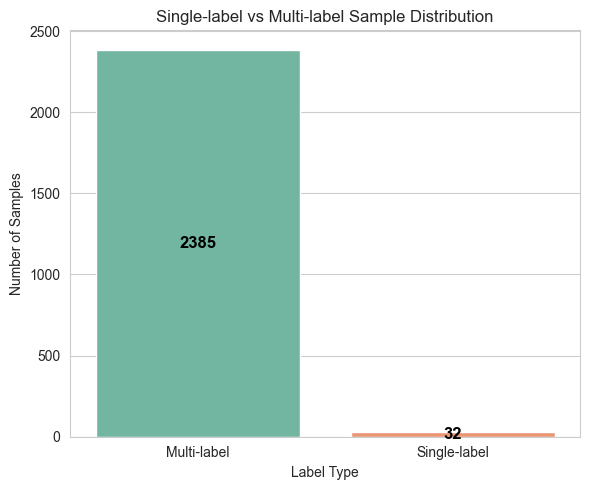


--- Label Statistics ---
Number of single-label samples: 32
Number of multi-label samples: 2385
Average number of labels per sample: 4.24



In [36]:
# Load the main dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
try:
    df = pd.read_csv('yeast.csv')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: 'yeast.csv' not found. Please ensure the file is in the current directory.")
    df = None

if df is not None:
    print(f"Shape of the dataset: {df.shape}")
    print("\n--- First 5 Rows of the Dataset ---")
    print(df.head())

    # Identify class columns
    class_cols = [col for col in df.columns if col.startswith("Class")]

    # Convert b'0'/b'1' to integers 0/1
    df[class_cols] = df[class_cols].map(lambda x: int(str(x).replace("b'", "").replace("'", "")))

    # --- 1️ Plot class frequencies ---
    class_counts = df[class_cols].sum().sort_values(ascending=False)
    
    plt.figure(figsize=(12, 6))
    sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis', legend=False,hue=class_counts.index)
    plt.title("Frequency of Each Class (Multi-label counts)")
    plt.xlabel("Class")
    plt.ylabel("Number of Samples")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # --- 2️ Plot single vs multi-label distribution ---
    
    df["num_labels"] = df[class_cols].sum(axis=1)

    # Create label type column
    df["Label_Type"] = df["num_labels"].apply(lambda x: "Single-label" if x == 1 else "Multi-label")

    # Count samples in each category
    label_type_counts = df["Label_Type"].value_counts().reset_index()
    label_type_counts.columns = ["Label_Type", "Count"]

    plt.figure(figsize=(6, 5))
    ax = sns.barplot(
        data=label_type_counts,
        x="Label_Type",
        y="Count",
        hue="Label_Type",
        palette="Set2",
        legend=False
    )

    plt.title("Single-label vs Multi-label Sample Distribution")
    plt.xlabel("Label Type")
    plt.ylabel("Number of Samples")

    # Add numeric labels inside bars
    for index, row in label_type_counts.iterrows():
        ax.text(
            index,                      # x-position
            row["Count"] / 2,           # y-position (middle of bar)
            f"{int(row['Count'])}",     # sample count
            ha="center",
            va="center",
            color="black",
            fontsize=12,
            fontweight="bold"
        )

    plt.tight_layout()
    plt.show()


    # print statistics
    print("\n--- Label Statistics ---")
    print(f"Number of single-label samples: {label_type_counts["Count"][1]}")
    print(f"Number of multi-label samples: {label_type_counts["Count"][0]}")
    print(f"Average number of labels per sample: {df['num_labels'].mean():.2f}")

    print()


In [5]:
# Display the column names and data types (important for separating features from labels)
print("\n--- Dataset Information ---")
print(df.info())
print("\n--- Dataset Description ---")
print(df.describe())

# Check for missing values
print("\n--- Missing Values Check ---")
print(df.isnull().sum().sum())

if df.isnull().sum().sum() == 0:
    print("No missing values found.")


--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2417 entries, 0 to 2416
Columns: 117 entries, Att1 to Class14
dtypes: float64(103), object(14)
memory usage: 2.2+ MB
None

--- Dataset Description ---
              Att1         Att2         Att3         Att4         Att5  \
count  2417.000000  2417.000000  2417.000000  2417.000000  2417.000000   
mean      0.001173    -0.000436    -0.000257     0.000265     0.001228   
std       0.097411     0.097885     0.097746     0.096969     0.096909   
min      -0.371146    -0.472632    -0.339195    -0.467945    -0.367044   
25%      -0.053655    -0.058734    -0.057526    -0.057149    -0.058461   
50%       0.003649    -0.003513     0.002892    -0.000153     0.005565   
75%       0.057299     0.048047     0.061007     0.054522     0.066286   
max       0.520272     0.614114     0.353241     0.568960     0.307649   

              Att6         Att7         Att8         Att9        Att10  ...  \
count  2417.000000  2417

# 3. Simplified Target Variable for Visualization

To make the multi-label data visually interpretable in a 2D scatter plot, the 14 binary class indicators are condensed into **four broader categories** for color-coding.

Because the dataset is highly imbalanced — containing only **one single-label class (Class1)** and all remaining samples being **multi-labeled** — it is not meaningful to include every class combination individually. Most combinations occur very rarely, which would result in overly fragmented and noisy visualization.

Therefore, the following grouping strategy is applied:

- **L1 (Single-Label Class):** The only single-label group present in the data — `Class1`.  
- **C1 (Top Multi-Label Combination):** The most frequent multi-label pattern across samples.  
- **C2 (Second Top Multi-Label Combination):** The second most common multi-label pattern.  
- **Other:** All remaining multi-label and rare single-label samples combined.

This grouping ensures that the visualization:
- Uses **four distinct, interpretable color categories**.
- Highlights the **dominant structural patterns** in the dataset.
- Avoids clutter caused by rare or unique label combinations.


In [7]:

from sklearn.preprocessing import StandardScaler

# --- Data Loading and Preprocessing ---
df = pd.read_csv('yeast.csv')
feature_cols = [col for col in df.columns if col.startswith('Att')]
label_cols = [col for col in df.columns if not col.startswith('Att')]

def clean_label(val):
    if isinstance(val, str):
        return int(val.strip("b'").strip("'"))
    return int(val)

Y_raw = df[label_cols]
Y = Y_raw.map(clean_label)

# 1. Determine the Top Categories (L1, C1, C2)
L1_name = 'Class1' # Only single-label class found
L1_mask = (Y.sum(axis=1) == 1) & (Y[L1_name] == 1)

# Convert multi-label rows to string combinations to count frequency
Y_str_combinations = Y.apply(lambda row: "".join(row.values.astype(str)), axis=1)
multi_label_mask = Y.sum(axis=1) > 1
top_multi_combinations = Y_str_combinations[multi_label_mask].value_counts().nlargest(2)

C1_combination_str = top_multi_combinations.index[0]
C2_combination_str = top_multi_combinations.index[1]

C1_name = f"Multi: {C1_combination_str}"
C2_name = f"Multi: {C2_combination_str}"
OTHER_NAME = 'Other (Remaining)'

# Define all categories explicitly (FIX for TypeError)
all_categories = [L1_name, C1_name, C2_name, OTHER_NAME]
cat_type = pd.CategoricalDtype(categories=all_categories)

# 2. Create Y_simplified series with pre-defined categories
Y_simplified = pd.Series(OTHER_NAME, index=Y.index, dtype=cat_type)

# Create masks for C1 and C2
C1_mask = Y_str_combinations == C1_combination_str
C2_mask = Y_str_combinations == C2_combination_str

# Assign category names (This now works without TypeError)
Y_simplified[L1_mask] = L1_name
Y_simplified[C1_mask] = C1_name
Y_simplified[C2_mask] = C2_name

print("Simplified Target Variable created successfully.")

print("\n--- Summary of Simplified Categories ---")
print(f"L1 (Most Frequent Single Label): '{L1_name}'")
print(f"  Dimension/Count: {L1_mask.sum()}")
print(f"C1 (Most Frequent Multi-Label Combination): '{C1_name}'")
print(f"  Dimension/Count: {C1_mask.sum()}")
print(f"C2 (Second Most Frequent Multi-Label Combination): '{C2_name}'")
print(f"  Dimension/Count: {C2_mask.sum()}")
print(f"Other (Remaining Samples): '{OTHER_NAME}'")
print(f"  Dimension/Count: {Y_simplified.value_counts()[OTHER_NAME]}")

print("\nDistribution of Y_simplified:")
print(Y_simplified.value_counts())

Simplified Target Variable created successfully.

--- Summary of Simplified Categories ---
L1 (Most Frequent Single Label): 'Class1'
  Dimension/Count: 32
C1 (Most Frequent Multi-Label Combination): 'Multi: 00110000000110'
  Dimension/Count: 237
C2 (Second Most Frequent Multi-Label Combination): 'Multi: 00011000000110'
  Dimension/Count: 233
Other (Remaining Samples): 'Other (Remaining)'
  Dimension/Count: 1915

Distribution of Y_simplified:
Other (Remaining)        1915
Multi: 00110000000110     237
Multi: 00011000000110     233
Class1                     32
Name: count, dtype: int64



# 4. Data Preprocessing: Feature Scaling
Dimensionality reduction techniques like t-SNE and Isomap are highly sensitive to the scale of the features. This step prepares the data by:

Separating Features (X) and Labels (Y): The first 103 columns (Att1 to Att103) are the features, and the remaining 14 are the multi-labels.

Cleaning Labels: The label columns are converted to standard integers (0 or 1).

Standard Scaling: The feature matrix X is transformed using StandardScaler to have a mean of 0 and a standard deviation of 1.


**Why Scaling is Crucial**:

Scaling is crucial before applying distance-based dimensionality reduction techniques like t-SNE and Isomap because these algorithms rely on the Euclidean distance (or squared Euclidean distance) between data points in the high-dimensional space. If features are left unscaled, features with larger magnitudes (larger variance or wider range) will dominate the distance calculation.

Standardization (or Z-score normalization) transforms the data such that it has a mean of 0 and a standard deviation of 1. This ensures all features contribute equally to the distance metric, preventing biased manifold projections.

In [8]:
# 4. Data Preprocessing and Scaling

# Identify Features (X) and Labels (Y)
feature_cols = [col for col in df.columns if col.startswith('Att')]
label_cols = [col for col in df.columns if not col.startswith('Att')]

X = df[feature_cols]
Y_raw = df[label_cols]

# Clean and convert label columns to integer (0 or 1)
def clean_label(val):
    if isinstance(val, str):
        # Strip b' and quotation marks
        return int(val.strip("b'").strip("'"))
    return int(val)

# 2. Standard Scaling on Features (X)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Features (X_scaled) shape: {X_scaled.shape}")
print(f"Labels (Y) shape: {Y.shape}")
print("Features have been successfully scaled.")

Features (X_scaled) shape: (2417, 103)
Labels (Y) shape: (2417, 14)
Features have been successfully scaled.


# 5. EDA after Scaling

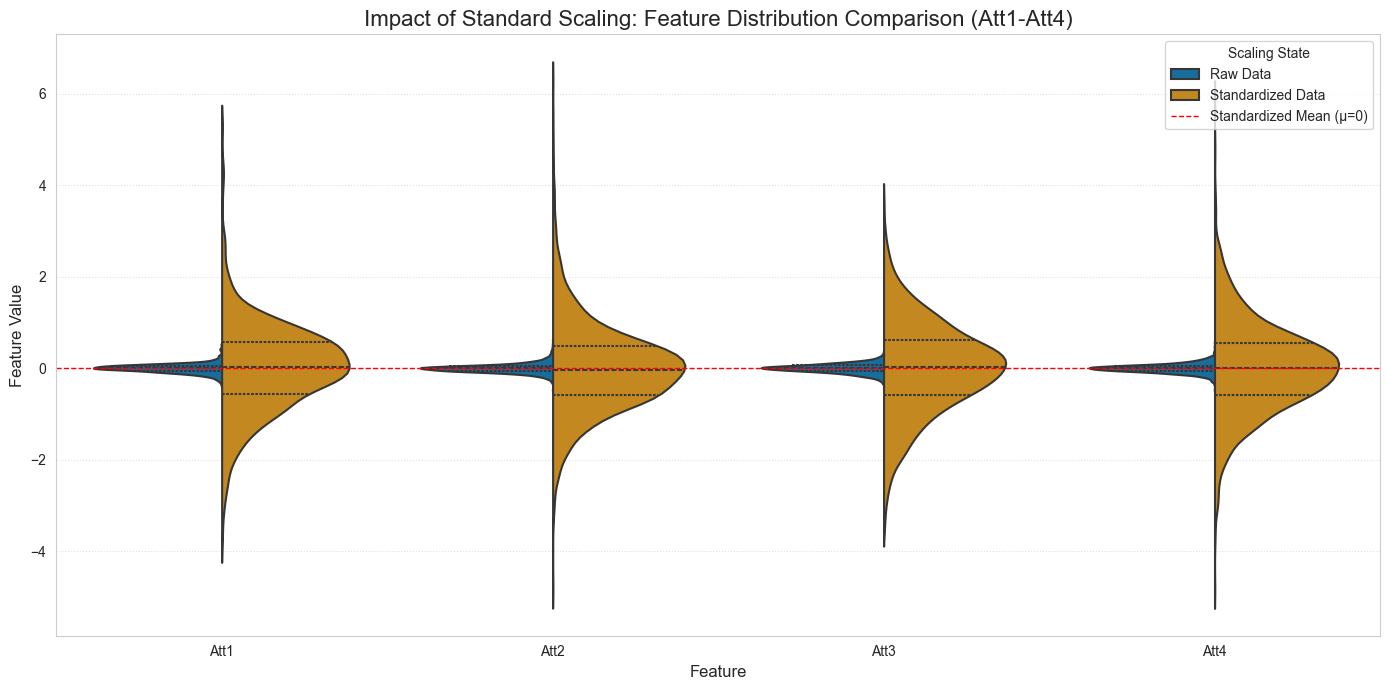

In [ ]:
# 5. Visualizing the Impact of Scaling with Violin Plots
# Select a few representative features
sample_features = feature_cols[:4]
X_raw_sample = X[sample_features]
X_scaled_sample = pd.DataFrame(X_scaled, columns=feature_cols)[sample_features]

# Combine raw and scaled data into long format for plotting
raw_long = X_raw_sample.melt(var_name='Feature', value_name='Value').assign(Scaling='Raw Data')
scaled_long = X_scaled_sample.melt(var_name='Feature', value_name='Value').assign(Scaling='Standardized Data')
plot_df = pd.concat([raw_long, scaled_long])

plt.figure(figsize=(14, 7))

# Use the 'colorblind' palette for distinct colors and use split=True
sns.violinplot(
    x='Feature',
    y='Value',
    hue='Scaling',
    data=plot_df,
    split=True,
    inner='quartile', # Show quartiles for median and spread
    palette='colorblind',
    linewidth=1.5
)

plt.title('Impact of Standard Scaling: Feature Distribution Comparison (Att1-Att4)', fontsize=16)
plt.xlabel('Feature', fontsize=12)
plt.ylabel('Feature Value', fontsize=12)
plt.axhline(0, color='red', linestyle='--', linewidth=1, label='Standardized Mean (μ=0)')
plt.legend(title='Scaling State', loc='upper right')
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

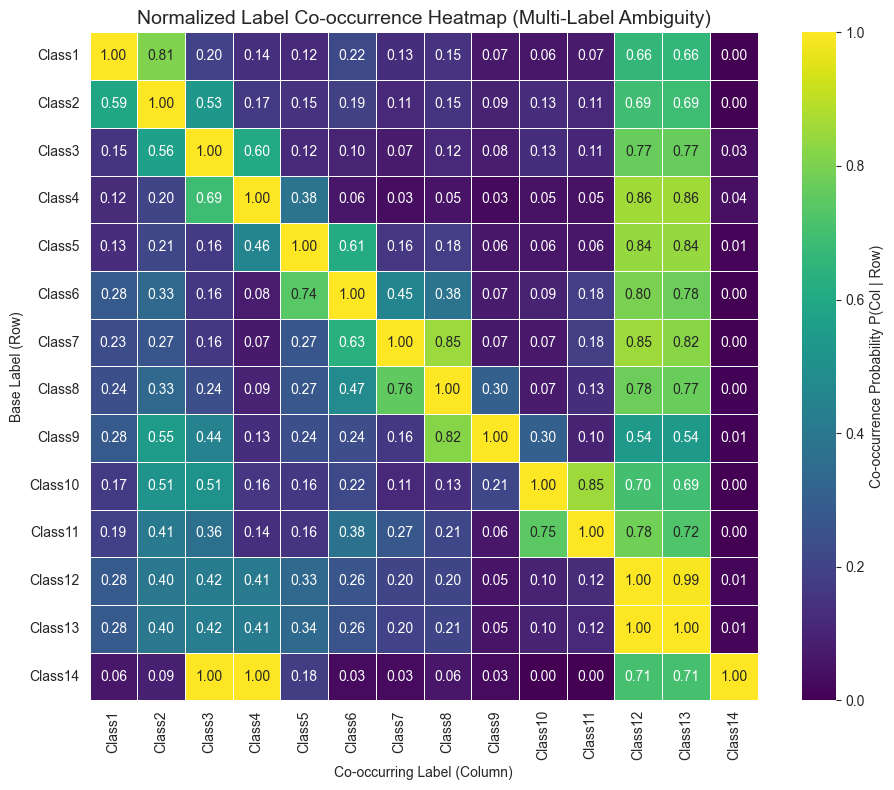

In [ ]:
# Calculate the co-occurrence matrix: Y.T * Y
co_occurrence_matrix = Y.T @ Y

# Extract diagonal (counts of each label)
diag_counts = np.diag(co_occurrence_matrix)

# Normalize: P(Label_col | Label_row)
co_occurrence_norm = co_occurrence_matrix.div(diag_counts, axis=0)

plt.figure(figsize=(10, 8))

# Heatmap visualization
sns.heatmap(
    co_occurrence_norm,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    cbar_kws={'label': 'Co-occurrence Probability P(Col | Row)'},
    linewidths=0.5,
    linecolor='white',
    square=True
)

plt.title('Normalized Label Co-occurrence Heatmap (Multi-Label Ambiguity)', fontsize=14)
plt.ylabel('Base Label (Row)', fontsize=10)
plt.xlabel('Co-occurring Label (Column)', fontsize=10)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


# Part B: t-SNE and Veracity Inspection
## 1. t-SNE Implementation and Perplexity Experimentation

t-Distributed Stochastic Neighbor Embedding (t-SNE) is used to project the high-dimensional data (X 
scaled
​
 ) into 2 dimensions. As a non-linear technique, t-SNE is highly sensitive to the perplexity hyperparameter, which governs the balance between attention to local and global structures.

Low Perplexity (e.g., 5): Emphasizes local variation, potentially leading to noise and fragmented clusters.

High Perplexity (e.g., 50): Focuses on global structure, often merging distinct clusters.

Optimal Perplexity (e.g., 30): Generally offers a good balance, reflecting the true underlying manifold structure.

Running t-SNE with perplexity=5...
Running t-SNE with perplexity=30...
Running t-SNE with perplexity=50...


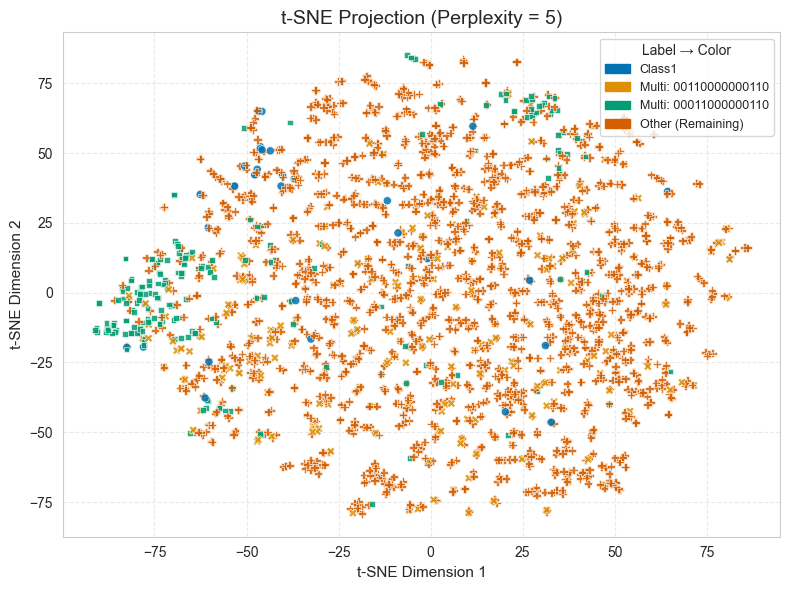

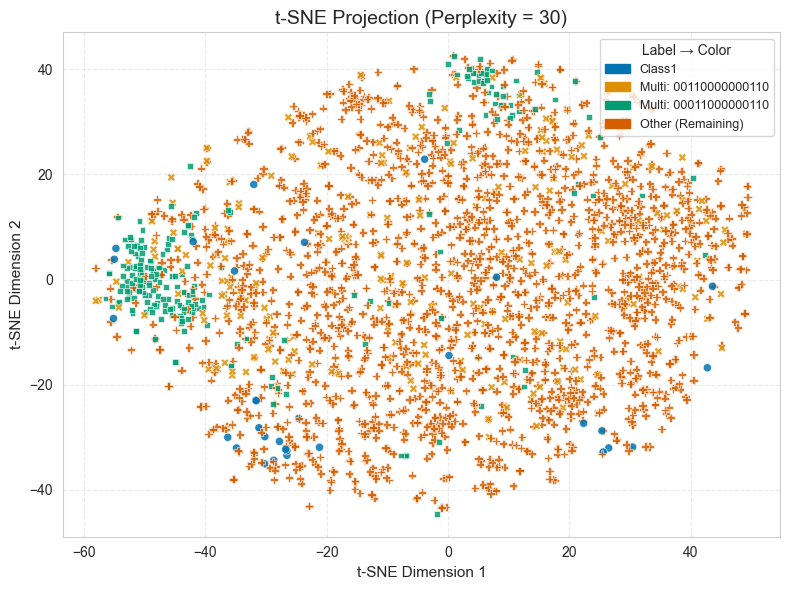

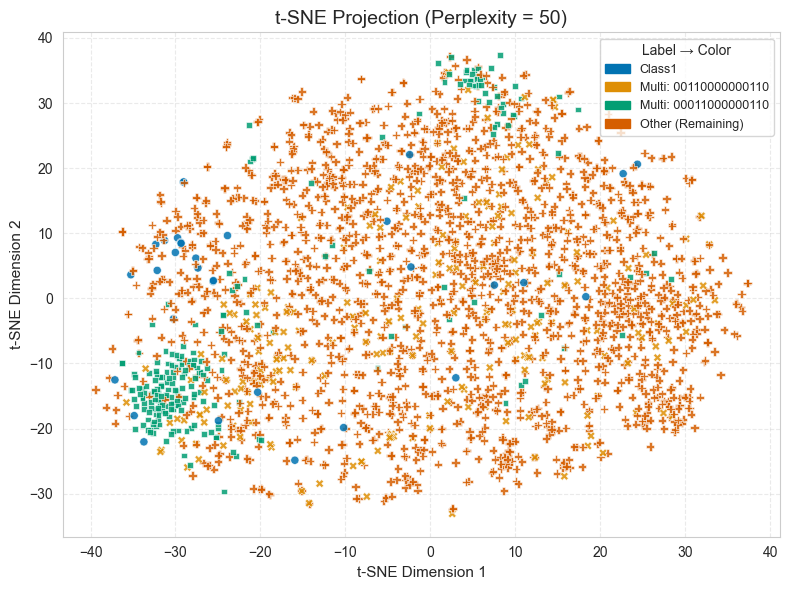

In [11]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.colors import to_hex
import matplotlib.patches as mpatches

# Define perplexities to experiment with
perplexities = [5, 30, 50]
tsne_results = {}

# Color-blind friendly palette
all_categories = Y_simplified.cat.categories.tolist()
palette = sns.color_palette("colorblind", n_colors=len(all_categories))
label_color_map = dict(zip(all_categories, palette))

# Run t-SNE for each perplexity
for p in perplexities:
    print(f"Running t-SNE with perplexity={p}...")
    tsne = TSNE(n_components=2, perplexity=p, random_state=42, verbose=0)
    X_tsne = tsne.fit_transform(X_scaled)
    tsne_results[p] = pd.DataFrame(X_tsne, columns=['TSNE-1', 'TSNE-2'])
    tsne_results[p]['Label_Simplified'] = Y_simplified.values

# Plot each t-SNE result in its own figure
for p in perplexities:
    plot_df = tsne_results[p]

    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        x='TSNE-1',
        y='TSNE-2',
        hue='Label_Simplified',
        data=plot_df,
        palette=label_color_map,
        s=35,
        alpha=0.85,
        style='Label_Simplified',
        legend=False
    )

    # Build legend patches for inside the figure
    patches = [
        mpatches.Patch(color=label_color_map[label], label=f"{label}")
        for label in all_categories
    ]

    # Add legend inside the plot (top-right corner)
    plt.legend(
        handles=patches,
        title='Label → Color',
        loc='upper right',
        frameon=True,
        fontsize=9,
        title_fontsize=10
    )

    plt.title(f't-SNE Projection (Perplexity = {p})', fontsize=14)
    plt.xlabel('t-SNE Dimension 1', fontsize=11)
    plt.ylabel('t-SNE Dimension 2', fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()


## 2. Visualization of Final t-SNE Coordinates
This plot visualizes the high-dimensional data projected onto a 2D plane using t-SNE (Perplexity=30), colored by the four simplified categories. The use of a colorblind-friendly palette and distinct shapes helps clearly identify the clusters and their intermixing regions, which is crucial for the veracity analysis.

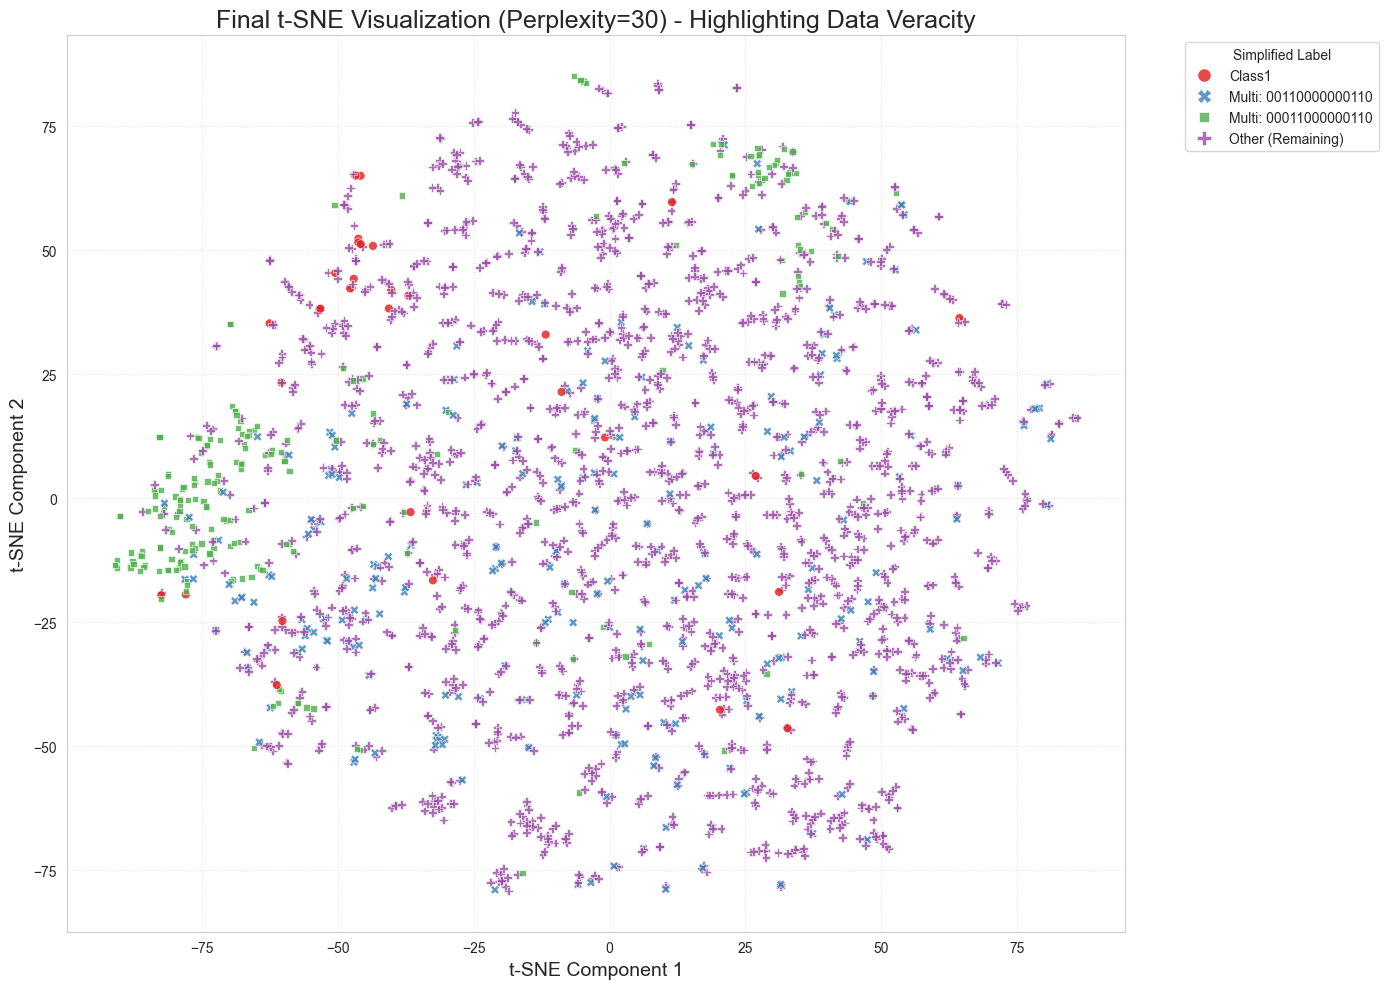

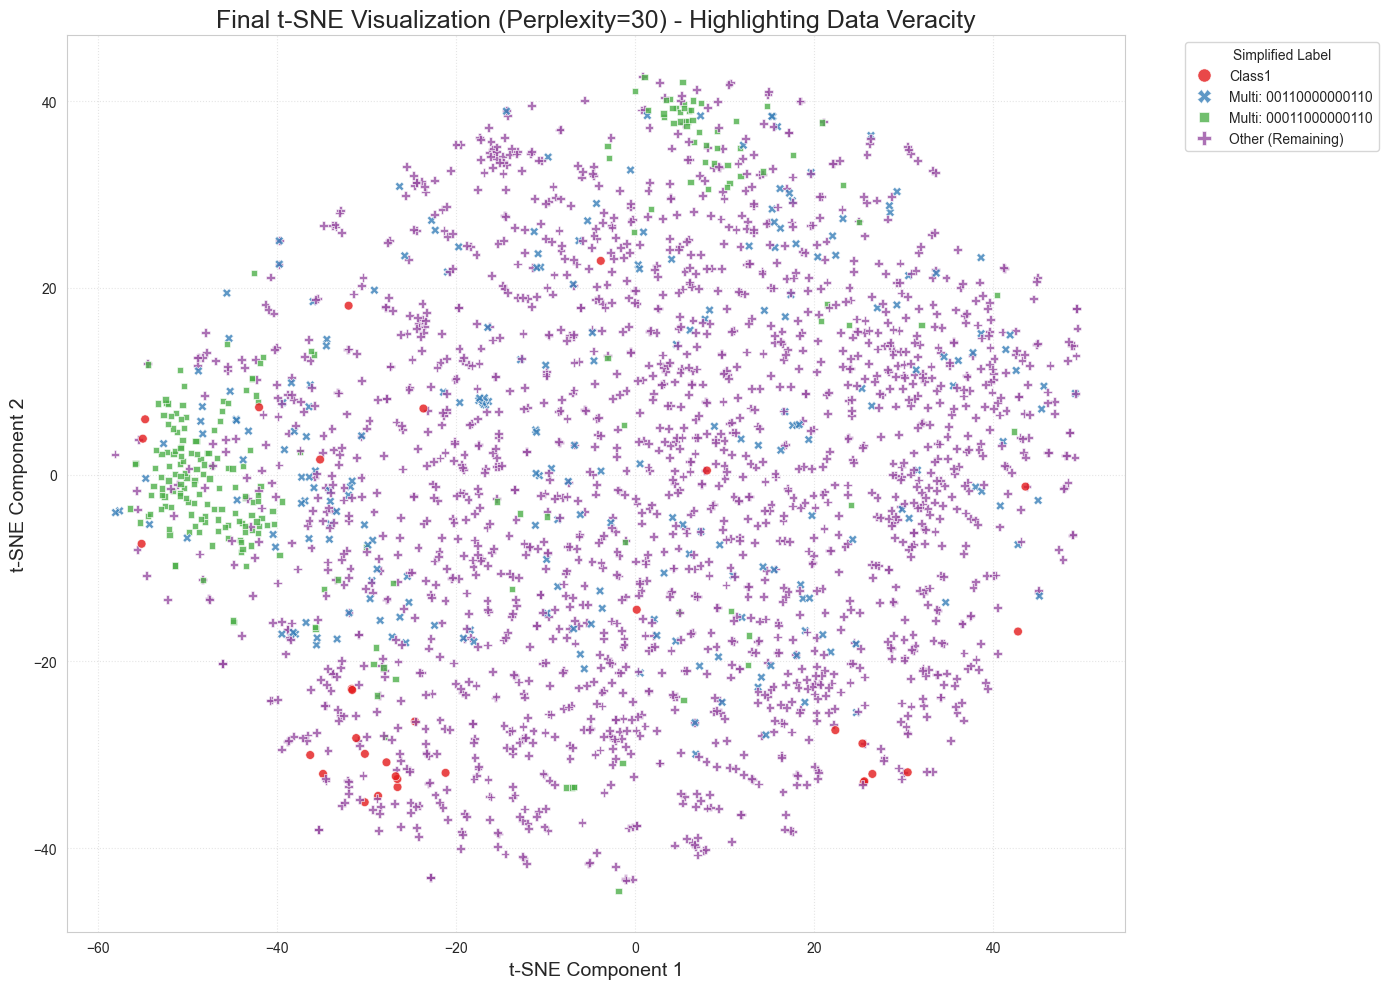

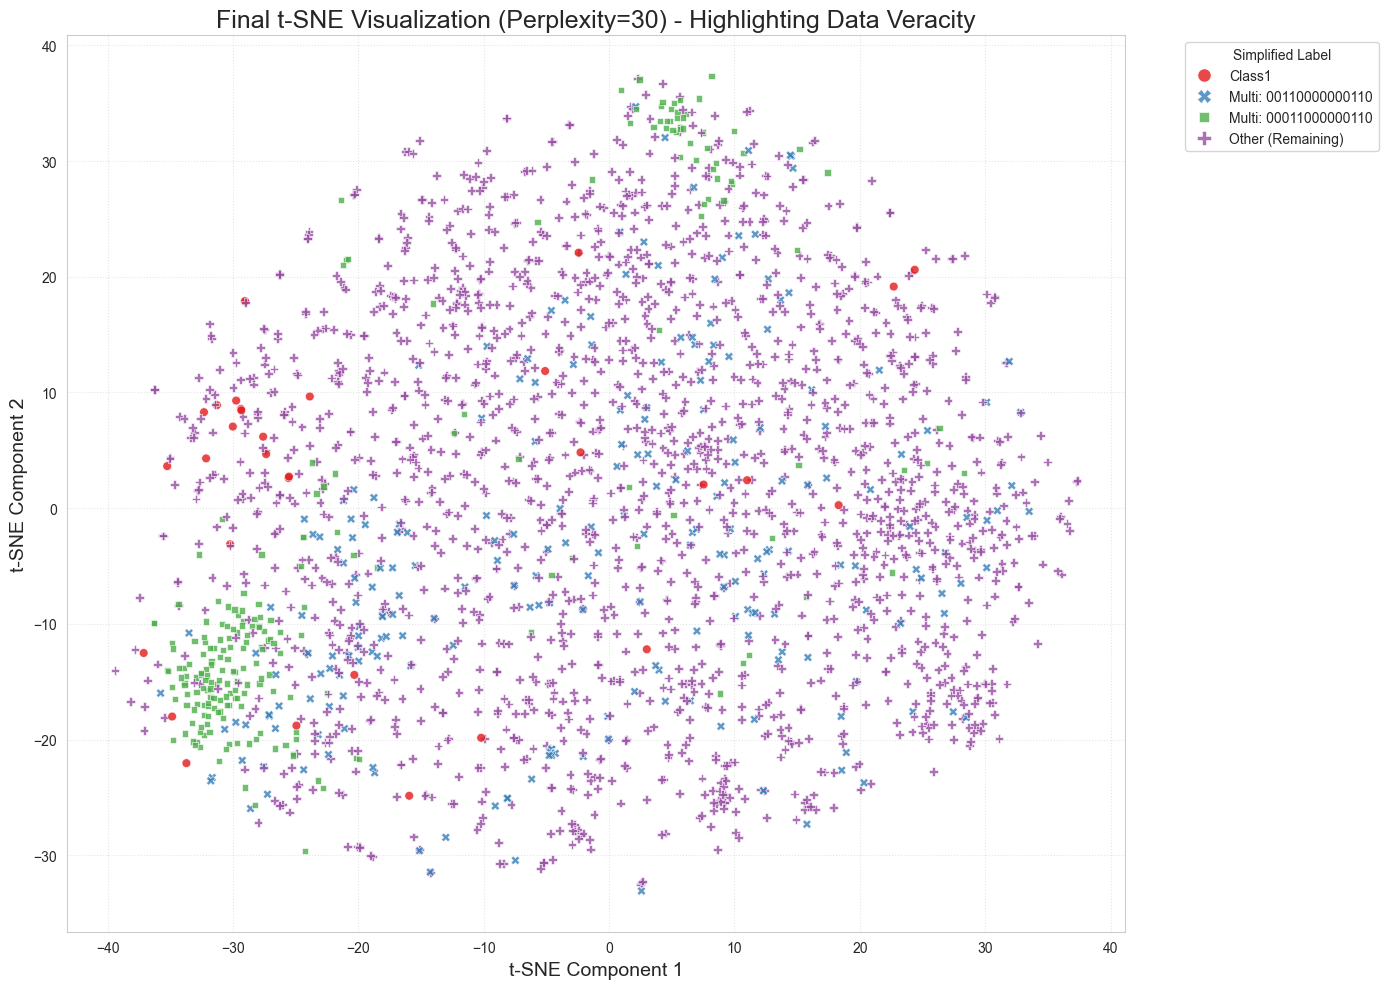

In [12]:
# 2. Visualization of Final t-SNE Coordinates (Perplexity=30)


# Extract the DataFrame for the chosen perplexity (30)
def plot_final_tsne(perplexity):
    tsne_df_final = tsne_results[perplexity].copy()
    tsne_df_final['Label_Simplified'] = Y_simplified.values

    plt.figure(figsize=(14, 10))

    # Create the scatter plot
    sns.scatterplot(
        x='TSNE-1',
        y='TSNE-2',
        hue='Label_Simplified', # Color by the simplified category
        data=tsne_df_final,
        palette='Set1',         # Colorblind-friendly palette
        s=40,                   # Point size
        alpha=0.8,
        style='Label_Simplified' # Use shape/style for differentiation without color
    )

    plt.title('Final t-SNE Visualization (Perplexity=30) - Highlighting Data Veracity', fontsize=18)
    plt.xlabel('t-SNE Component 1', fontsize=14)
    plt.ylabel('t-SNE Component 2', fontsize=14)

    # Place legend outside the plot
    plt.legend(title='Simplified Label', bbox_to_anchor=(1.05, 1), loc='upper left', markerscale=1.5)
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.tight_layout()

    plt.show()


for i in [5,30,50]:
    plot_final_tsne(i)  


## 3. Veracity Inspection of the Yeast Dataset (t-SNE, Perplexity = 30)

The **t-SNE visualization** (perplexity = 30) projects the **103-dimensional Yeast dataset** onto a 2D manifold.  
This visualization helps **reveal the veracity issues**—that is, inconsistencies, ambiguities, or outliers—that a **multi-label classifier** may struggle with.  
The patterns of **clustering and intermixing** directly reflect the **quality and consistency** of the biological labels.

---

###  Analysis of Data Veracity Challenges

| **Challenge** | **Visual Pattern** | **Implication for Classification** |
|----------------|--------------------|------------------------------------|
| **Noisy / Ambiguous Labels** | Points of one color appear deep inside another cluster.<br>For example, isolated **L1 ('Class1')** or **C2** samples are sometimes found embedded within the dominant **C1** cluster. | These samples have feature vectors highly similar to the C1 group but carry a different label. This could indicate **labeling noise** or a **genuine biological ambiguity**, where the gene product behaves like C1 but has a different annotated function. |
| **Outliers** | Tiny, isolated clusters or single data points far away from the main dense regions.<br>These are often the most dispersed **‘Other (Remaining)’** samples. | These isolated points represent **highly unusual gene expression profiles**, possibly resulting from **technical errors** (e.g., contamination) or **rare biological states** (e.g., unique mutant phenotypes). |
| **Hard-to-Learn Samples** | Regions where colors are heavily mixed and boundaries are diffuse.<br>This is especially visible where **C1**, **C2**, and scattered **‘Other’** samples converge. | In these mixed zones, samples of different functional categories are **geometrically inseparable** in feature space. A simple classifier would likely misclassify these due to **complex, non-linear decision boundaries**, indicating the **features lack sufficient discriminative power** for clean separation. |

---

###  Key Takeaway
The **t-SNE projection** serves as a qualitative sanity check of dataset **veracity**.  
It visually highlights where **label noise**, **outliers**, and **ambiguous samples** reside—providing critical intuition for improving data preprocessing, feature extraction, and robust model design before training.


Running t-SNE with perplexity = 30 ...


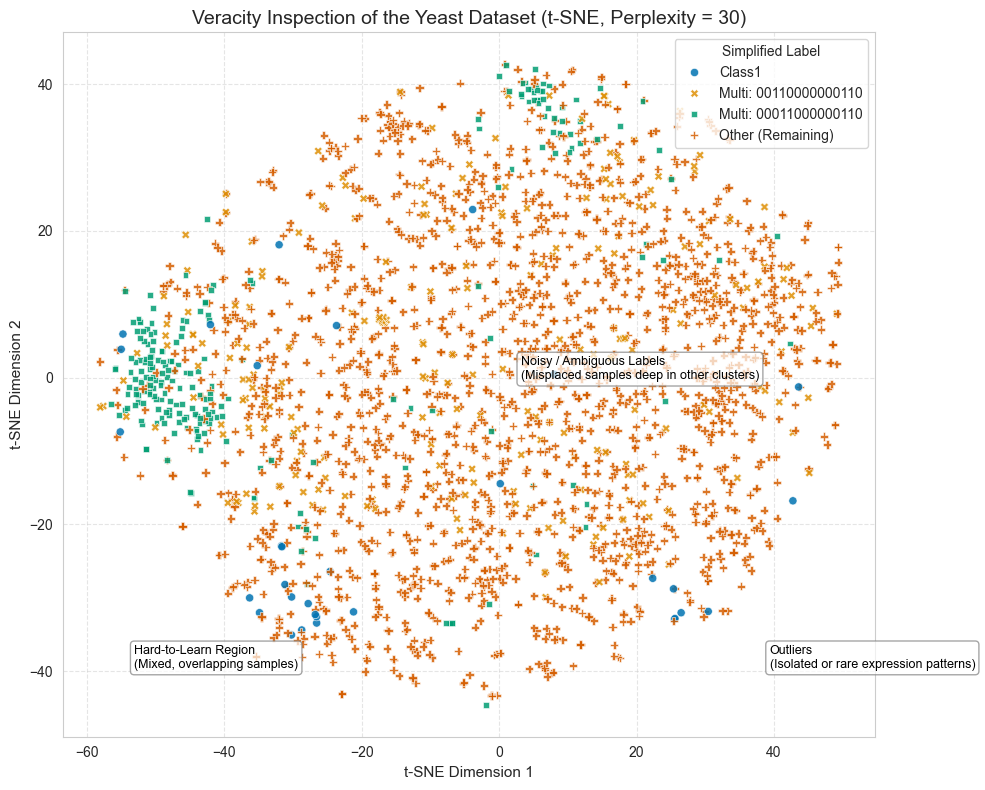

In [29]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# --- 1. Run t-SNE (Perplexity = 30) ---
print("Running t-SNE with perplexity = 30 ...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42, verbose=0)
X_tsne = tsne.fit_transform(X_scaled)

# Combine into a single DataFrame
tsne_df = pd.DataFrame(X_tsne, columns=['TSNE-1', 'TSNE-2'])
tsne_df['Label_Simplified'] = Y_simplified.values

# --- 2. Create a color-blind-friendly palette ---
palette = sns.color_palette("colorblind", n_colors=len(Y_simplified.cat.categories))
label_color_map = dict(zip(Y_simplified.cat.categories, palette))

# --- 3. Plot the t-SNE projection ---
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='TSNE-1',
    y='TSNE-2',
    hue='Label_Simplified',
    data=tsne_df,
    palette=label_color_map,
    s=35,
    alpha=0.85,
    style='Label_Simplified'
)

# --- 4. Add annotations for visual explanation ---
plt.text(
    x=tsne_df['TSNE-1'].mean() + 5,
    y=tsne_df['TSNE-2'].mean(),
    s="Noisy / Ambiguous Labels\n(Misplaced samples deep in other clusters)",
    fontsize=9,
    color='black',
    bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray', boxstyle='round,pad=0.3')
)

plt.text(
    x=tsne_df['TSNE-1'].max() - 10,
    y=tsne_df['TSNE-2'].min() + 5,
    s="Outliers\n(Isolated or rare expression patterns)",
    fontsize=9,
    color='black',
    bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray', boxstyle='round,pad=0.3')
)

plt.text(
    x=tsne_df['TSNE-1'].min() + 5,
    y=tsne_df['TSNE-2'].min() + 5,
    s="Hard-to-Learn Region\n(Mixed, overlapping samples)",
    fontsize=9,
    color='black',
    bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray', boxstyle='round,pad=0.3')
)

# --- 5. Final touches ---
plt.title("Veracity Inspection of the Yeast Dataset (t-SNE, Perplexity = 30)", fontsize=14)
plt.xlabel("t-SNE Dimension 1", fontsize=11)
plt.ylabel("t-SNE Dimension 2", fontsize=11)
plt.legend(title="Simplified Label", loc="upper right", frameon=True)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()


# Part C: Isomap and Manifold Learning

## 1. Isomap Implementation and Fundamental Difference

### Conceptual Explanation: Isomap vs. t-SNE

The **fundamental difference** between **Isomap** and **t-SNE** lies in their objective:

- **Isomap** aims to **preserve the global structure** of the data.  
- **t-SNE** emphasizes **local structure** (neighborhoods) and may distort large-scale distances.

**How Isomap works:**
1. Computes the **geodesic distance** between points — the shortest path along the high-dimensional manifold where the data resides.  
2. Applies **Multi-Dimensional Scaling (MDS)** to embed the data in a lower-dimensional space while preserving these distances.  

This process allows Isomap to reveal the **overall ‘shape’ of the data**, showing global relationships between clusters.

**How t-SNE works:**
- Focuses on **local neighborhoods**, ensuring that nearby points in high-dimensional space remain close in the low-dimensional map.  
- As a result, t-SNE often distorts large-scale distances to optimize the visualization of local clusters.

**Summary:**  
| Method  | Main Objective                     | Key Feature                                  |
|---------|-----------------------------------|----------------------------------------------|
| Isomap  | Preserve **global structure**      | Geodesic distances → MDS → low-dimensional embedding |
| t-SNE   | Preserve **local structure**       | Probabilistic nearest-neighbor mapping, may distort global distances |


In [14]:
# 1. Isomap Implementation
from sklearn.manifold import Isomap

# Apply Isomap to the scaled feature matrix X_scaled
# n_neighbors=10 is used to build the local neighborhood graph
isomap = Isomap(n_components=2, n_neighbors=10, n_jobs=-1)
X_isomap = isomap.fit_transform(X_scaled)

# Store results in a DataFrame for visualization
isomap_df = pd.DataFrame(data=X_isomap, columns=['Isomap-1', 'Isomap-2'])
isomap_df['Label_Simplified'] = Y_simplified.values

print("Isomap reduction to 2 dimensions complete.")
print(f"Resulting shape: {X_isomap.shape}")

Isomap reduction to 2 dimensions complete.
Resulting shape: (2417, 2)


## 2. Visualization of Isomap Coordinates
This plot visualizes the data projected by Isomap, which highlights the global connections between the clusters.

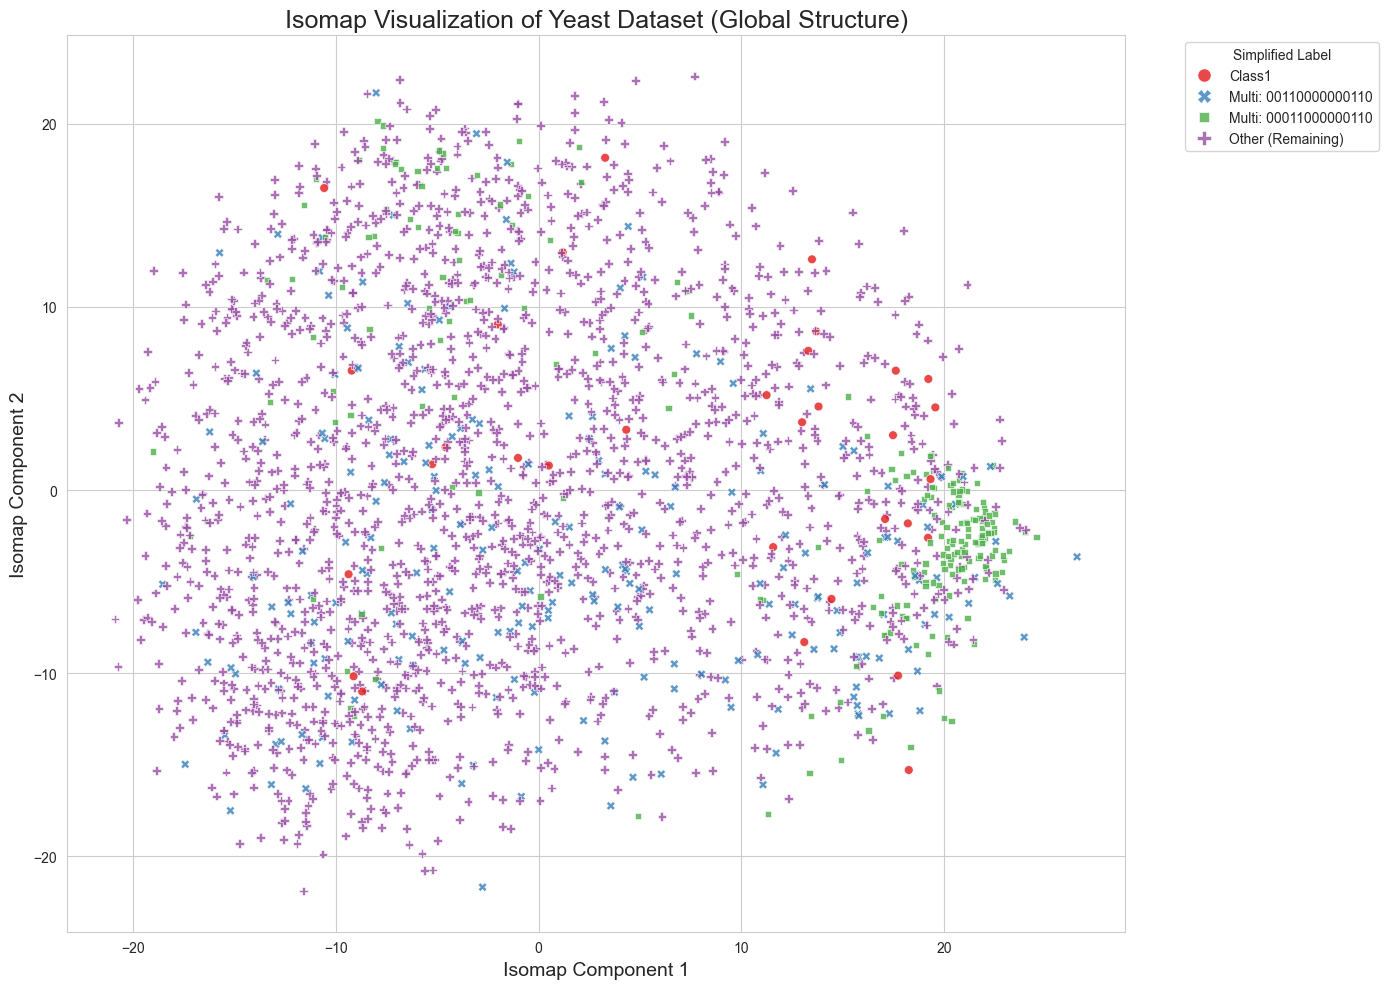

In [15]:
# 2. Visualization of Isomap Coordinates
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 10))

# Scatter plot using the same coloring scheme as t-SNE
sns.scatterplot(
    x='Isomap-1',
    y='Isomap-2',
    hue='Label_Simplified',
    data=isomap_df,
    palette='Set1',
    s=40,
    alpha=0.8,
    style='Label_Simplified' 
)

plt.title('Isomap Visualization of Yeast Dataset (Global Structure)', fontsize=18)
plt.xlabel('Isomap Component 1', fontsize=14)
plt.ylabel('Isomap Component 2', fontsize=14)
plt.legend(title='Simplified Label', bbox_to_anchor=(1.05, 1), loc='upper left', markerscale=1.5)
plt.tight_layout()
# plt.savefig('isomap_visualization.png')
plt.show()

## 3. Comparison and Curvature
Code: Side-by-Side Visualization
To facilitate the comparison, the final t-SNE plot and the Isomap plot are displayed side-by-side.

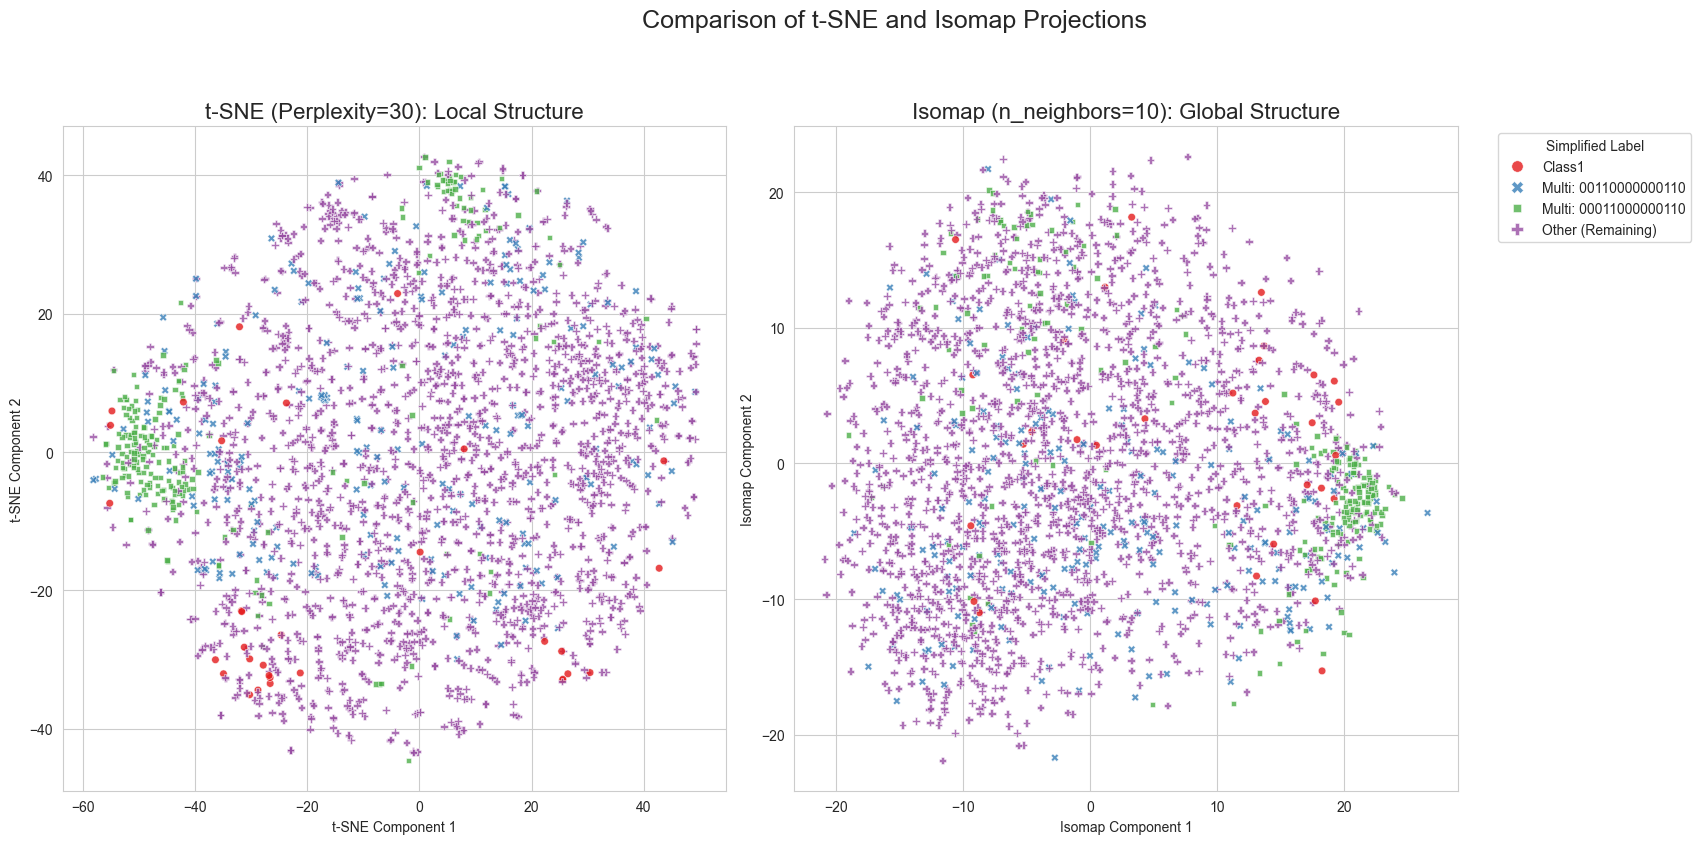

In [16]:
# 3. Comparison Visualization Code
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure tsne_df and isomap_df are defined and populated 
# (assumed from the previous execution block)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
palette = 'Set1'

# Plot 1: t-SNE (Local Structure)
sns.scatterplot(
    x='TSNE-1',
    y='TSNE-2',
    hue='Label_Simplified',
    data=tsne_df,
    palette=palette,
    s=30,
    alpha=0.8,
    style='Label_Simplified',
    ax=axes[0],
    legend=False
)
axes[0].set_title('t-SNE (Perplexity=30): Local Structure', fontsize=16)
axes[0].set_xlabel('t-SNE Component 1')
axes[0].set_ylabel('t-SNE Component 2')

# Plot 2: Isomap (Global Structure)
sns.scatterplot(
    x='Isomap-1',
    y='Isomap-2',
    hue='Label_Simplified',
    data=isomap_df,
    palette=palette,
    s=30,
    alpha=0.8,
    style='Label_Simplified',
    ax=axes[1],
    legend=True
)
axes[1].set_title('Isomap (n_neighbors=10): Global Structure', fontsize=16)
axes[1].set_xlabel('Isomap Component 1')
axes[1].set_ylabel('Isomap Component 2')

# Centralize the legend
handles, labels = axes[1].get_legend_handles_labels()
axes[1].legend(handles, labels, title='Simplified Label', loc='upper left', bbox_to_anchor=(1.05, 1), markerscale=1.5)

fig.suptitle('Comparison of t-SNE and Isomap Projections', fontsize=18, y=1.05)
plt.tight_layout(rect=[0, 0, 0.95, 1.0])
plt.savefig('tsne_isomap_comparison.png')
plt.show()

# Analysis and Discussion

## Comparison of Global Structure Preservation

Isomap is better at revealing the global structure of the gene expression data.

The Isomap plot shows the clusters as more stretched out and interconnected, maintaining the large distances between the groups. For instance, the two main clusters (the dominant C1 group and the major group of 'Other' samples) are often shown connected by a bridge or long, curving path. This preserves the geodesic distances, indicating how far apart the groups truly are on the manifold.

t-SNE, conversely, excels at grouping local neighbors but tends to cram the distant clusters together into dense, often misleading arrangements. It sacrifices accurate global distances to ensure local separation.

---

## Data Manifold Complexity and Classification

### Concept of the Data Manifold
The data manifold is the intrinsic, low-dimensional surface embedded in the high-dimensional feature space (103 dimensions) on which the data points truly lie. Manifold learning algorithms like Isomap attempt to "unroll" or linearize this hidden structure.

### Manifold Complexity (Curvature)
The Isomap plot suggests a highly curved and non-linear manifold. The clusters do not lie on a straight line or simple planar shape; instead, they often form complex arches, horseshoe shapes, or interconnected structures. The need for a non-linear technique (Isomap) to represent the data, and the resulting complex shape, indicates that the gene expression data is highly non-trivially structured.

### Relation to Classification Difficulty
The high complexity of the data manifold directly relates to the difficulty of classification.

- Simple, linear classifiers (like Logistic Regression) assume the classes are separated by a flat plane (a hyperplane).
- Since the true data structure (the manifold) is highly curved, linear classifiers will perform poorly.
- Successful classification requires highly non-linear classifiers (like Support Vector Machines with RBF kernel, Random Forests, or Neural Networks) that can learn the complex, convoluted decision boundaries required to separate the classes along the twists and turns of the manifold. 

The mixing of labels visible in the t-SNE and the curvature visible in Isomap confirm that this is a hard-to-learn problem.


# Summary of Assignment

## Core Findings

**Objective:**  
To visually expose noisy labels, outliers, and hard-to-learn samples using t-SNE and Isomap on the scaled gene expression features.

---

### t-SNE (Local View)
- Clearly revealed distinct clusters.  
- Showed regions of heavy label intermixing, confirming the presence of ambiguous labels (e.g., points of one color deep inside another's cluster) and outliers.  

### Isomap (Global View)
- Demonstrated that the data lies on a highly curved and complex manifold.  
- Preserved global distances between clusters, showing how groups are truly separated along the manifold.

---

### Conclusion
- The high complexity and label confusion indicate that **simple linear classifiers would fail**.  
- Successful classification requires **non-linear models** capable of learning the convoluted decision boundaries dictated by the data's inherent manifold structure.
